# **PRAKTIKUM PEMBELAJARAN MESIN**

**Nama**  : Mufliha Hafsyah Shahieza <br>
**NIM**   : 244107020147 <br>
**Kelas** : TI-3G

---

# **JS05 - Klasterisasi Hierarki**<hr>
# **Praktikum 1**<hr>
## **Persiapan Lingkungan**

In [1]:
# Instalasi pustaka hdbscan (tidak tersedia default di sklearn)
!pip install hdbscan

# Import modul
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import hdbscan
from sklearn.cluster import HDBSCAN

## **Langkah 2: Definisi Fungsi Visualisasi**

In [2]:
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # warna hitam untuk noise
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

## **Langkah 3: Membuat Dataset Sintetis**

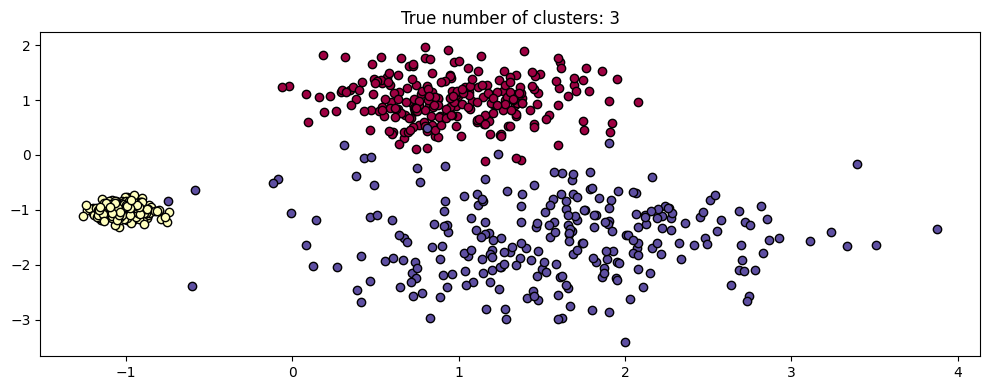

In [3]:
centers = [[1, 1], [-1, -1], [1.5, -1.5]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=[0.4, 0.1, 0.75], random_state=0
)

plot(X, labels=labels_true, ground_truth=True)

## **Langkah 4: Uji Scale Invariance pada DBSCAN**

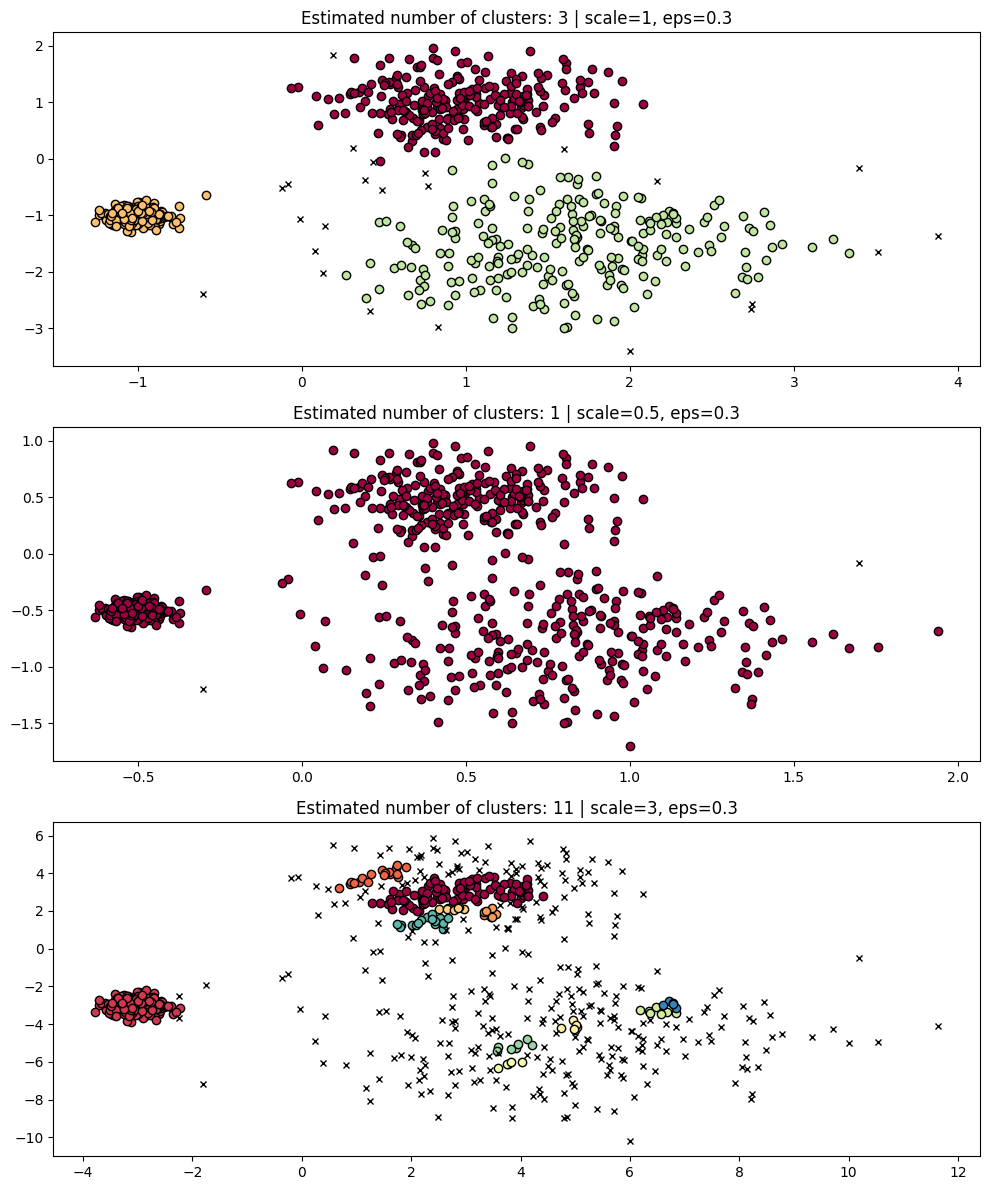

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
dbs = DBSCAN(eps=0.3)
for idx, scale in enumerate([1, 0.5, 3]):
    dbs.fit(X * scale)
    plot(X * scale, dbs.labels_, parameters={"scale": scale, "eps": 0.3}, ax=axes[idx])

Perbaiki dengan mengubah eps sesuai skala:

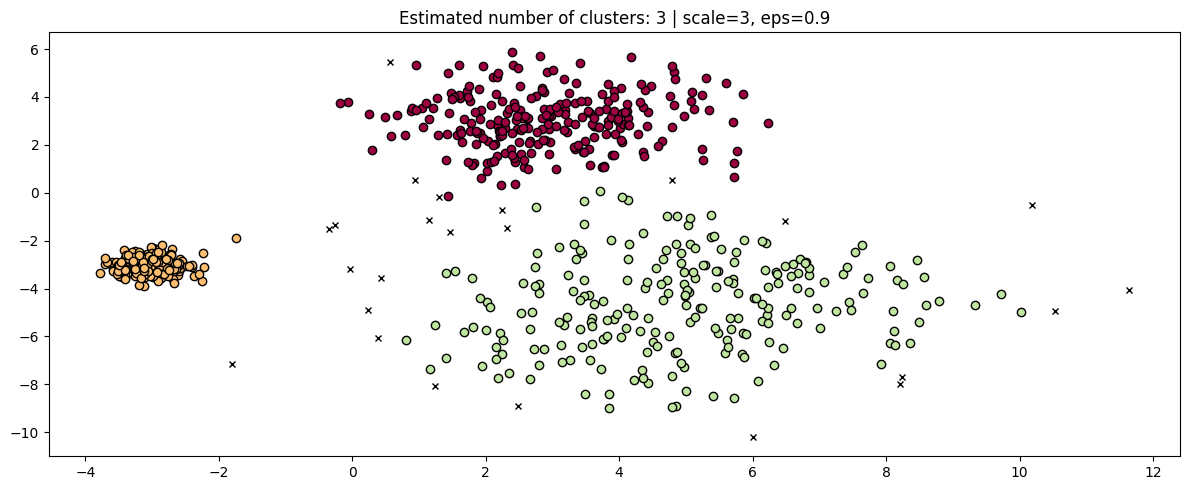

In [5]:
fig, axis = plt.subplots(1, 1, figsize=(12, 5))
dbs = DBSCAN(eps=0.9).fit(3 * X)
plot(3 * X, dbs.labels_, parameters={"scale": 3, "eps": 0.9}, ax=axis)

**Penjelasan**<br>
DBSCAN dengan `eps=0.3` yang sama memberi hasil yang berbeda ketika skala data diubah (1, 0.5, dan 3). Hal ini menunjukkan bahwa DBSCAN **tidak scale invariant**: `eps` adalah jarak absolut, sehingga ketika data diperbesar atau diperkecil, nilai `eps` harus ikut disesuaikan. Setelah `eps` dinaikkan menjadi 0.9 untuk data berskala 3, hasil clustering kembali sesuai.

## **Langkah 5: Bandingkan dengan HDBSCAN (lebih robust)**

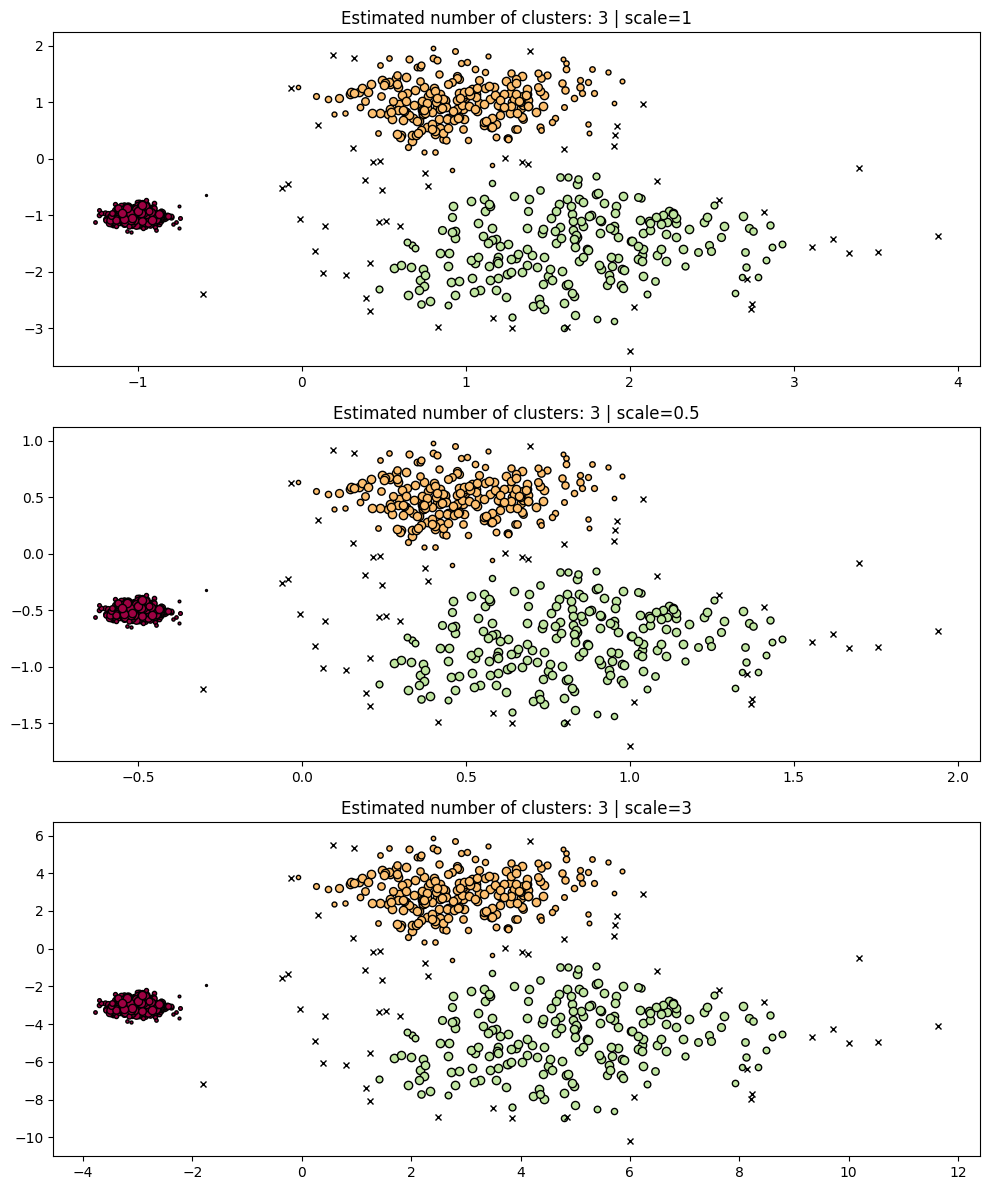

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
hdb = hdbscan.HDBSCAN()
for idx, scale in enumerate([1, 0.5, 3]):
    hdb.fit(X * scale)
    plot(X * scale, hdb.labels_, hdb.probabilities_, ax=axes[idx], parameters={"scale": scale})

**Penjelasan:**<br>
HDBSCAN menghasilkan clustering yang konsisten pada ketiga skala data tanpa perlu menyesuaikan parameter jarak. Hal ini karena HDBSCAN membangun hierarki cluster dan memilih cluster yang stabil, sehingga tidak bergantung pada satu nilai `eps` tetap seperti DBSCAN. Dengan demikian HDBSCAN lebih robust terhadap perubahan skala data.

## **Langkah 6: Multi-Scale Clustering**

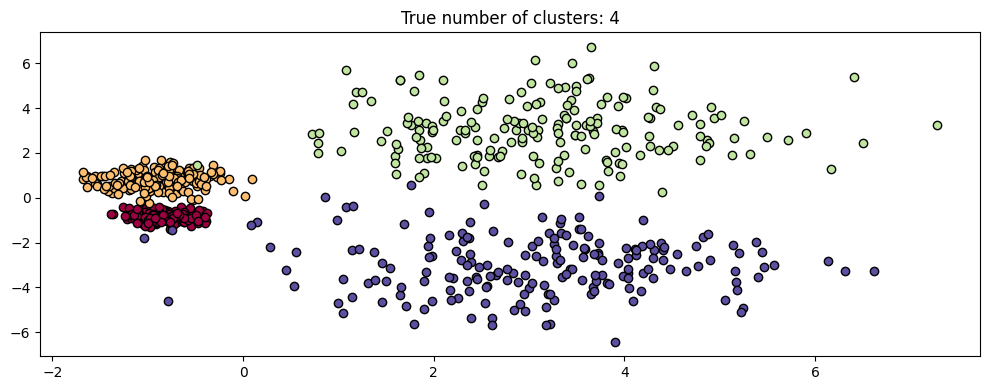

In [7]:
centers = [[-0.85, -0.85], [-0.85, 0.85], [3, 3], [3, -3]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=[0.2, 0.35, 1.35, 1.35], random_state=0
)
plot(X, labels=labels_true, ground_truth=True)

Bandingkan DBSCAN dengan eps berbeda:

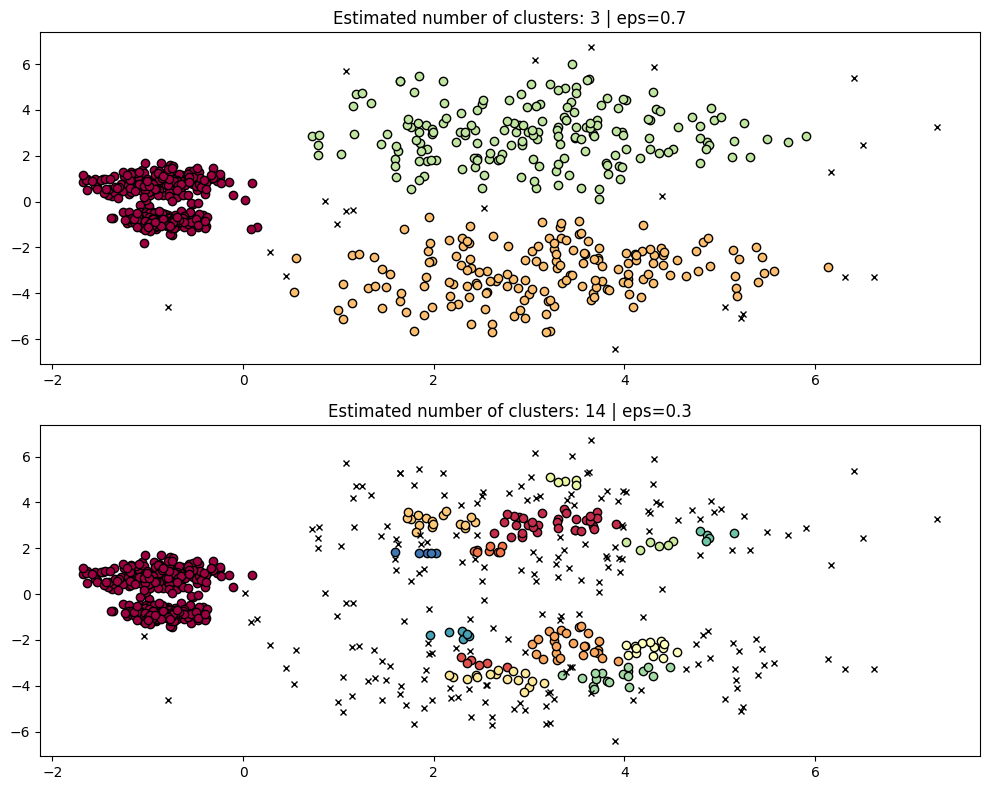

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
params = {"eps": 0.7}
dbs = DBSCAN(**params).fit(X)
plot(X, dbs.labels_, parameters=params, ax=axes[0])

params = {"eps": 0.3}
dbs = DBSCAN(**params).fit(X)
plot(X, dbs.labels_, parameters=params, ax=axes[1])

Jalankan HDBSCAN:

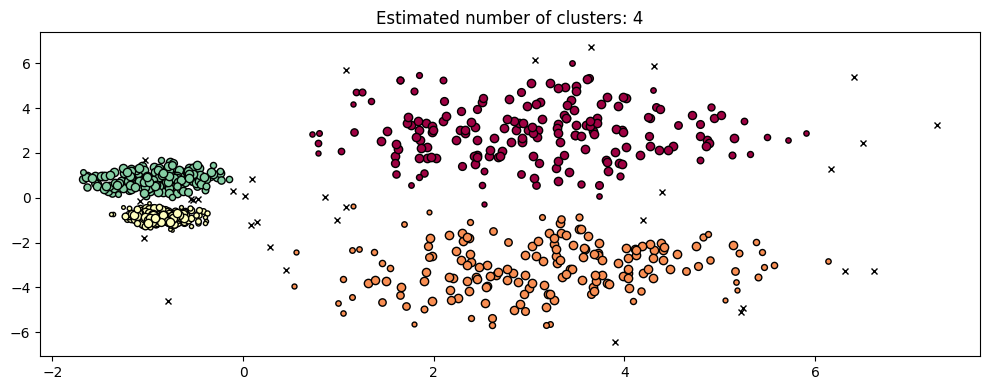

In [9]:
hdb = HDBSCAN(copy=True).fit(X)
plot(X, hdb.labels_, hdb.probabilities_)

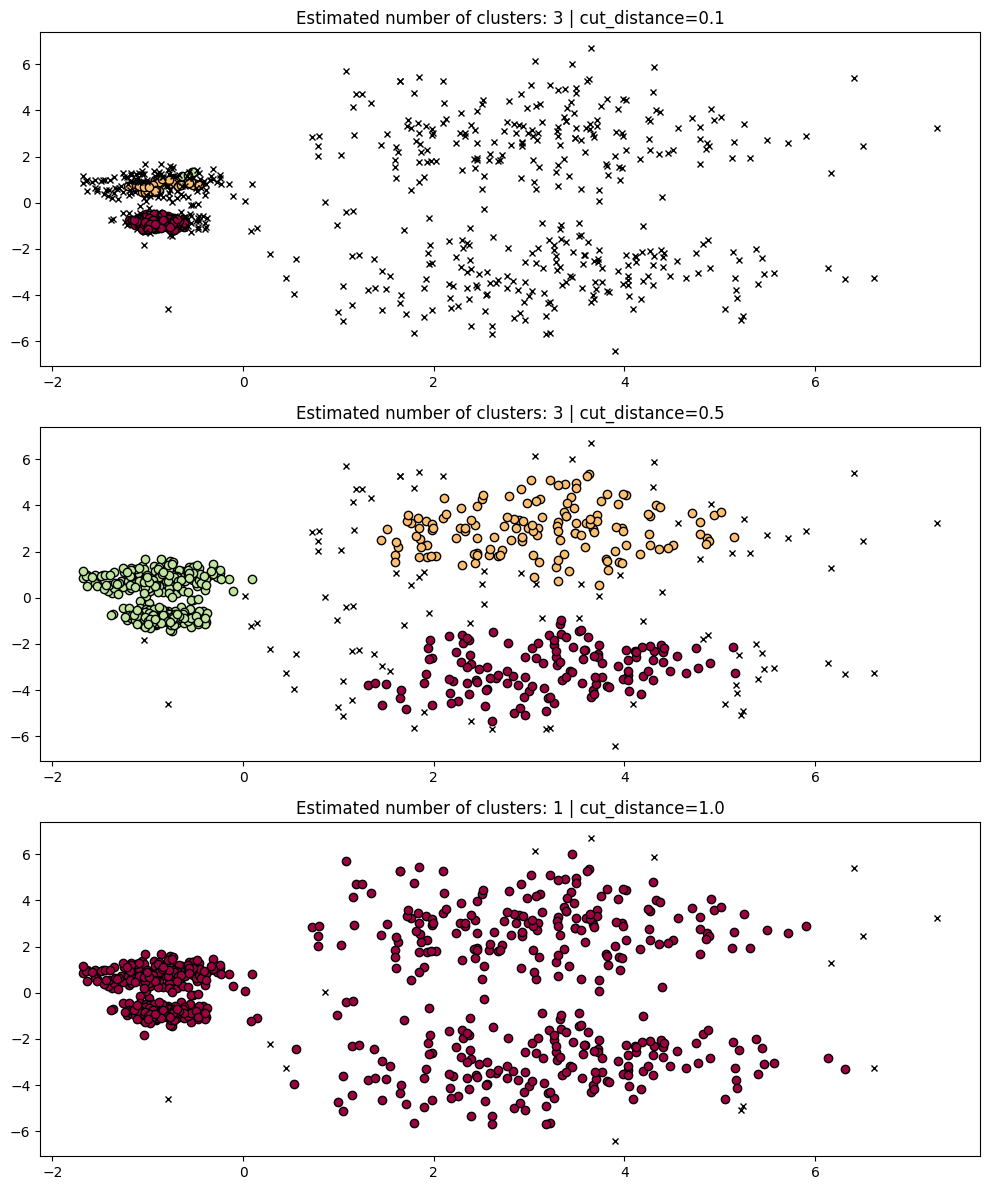

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for idx, cut_distance in enumerate((0.1, 0.5, 1.0)):
    labels = hdb.dbscan_clustering(cut_distance=cut_distance, min_cluster_size=5)
    plot(X, labels, parameters={"cut_distance": cut_distance}, ax=axes[idx])

**Penjelasan:**<br>
Dataset ini memiliki 4 cluster dengan kepadatan berbeda: dua cluster kecil dan padat di kiri, serta dua cluster besar dan renggang di kanan. DBSCAN dengan satu nilai `eps` tidak mampu menangani kondisi ini. Dengan `eps=0.7`, dua cluster padat yang berdekatan cenderung menyatu, sedangkan dengan `eps=0.3`, cluster renggang banyak berubah menjadi noise atau terpecah. HDBSCAN berhasil menemukan 4 cluster sesuai struktur sebenarnya tanpa perlu menentukan `eps`, karena mampu beradaptasi dengan kepadatan yang berbeda.

## **Langkah 7: Eksperimen Hyperparameter min_cluster_size**

min_cluster_size=5: 4 cluster, 32 noise
min_cluster_size=3: 90 cluster, 254 noise
min_cluster_size=25: 4 cluster, 90 noise


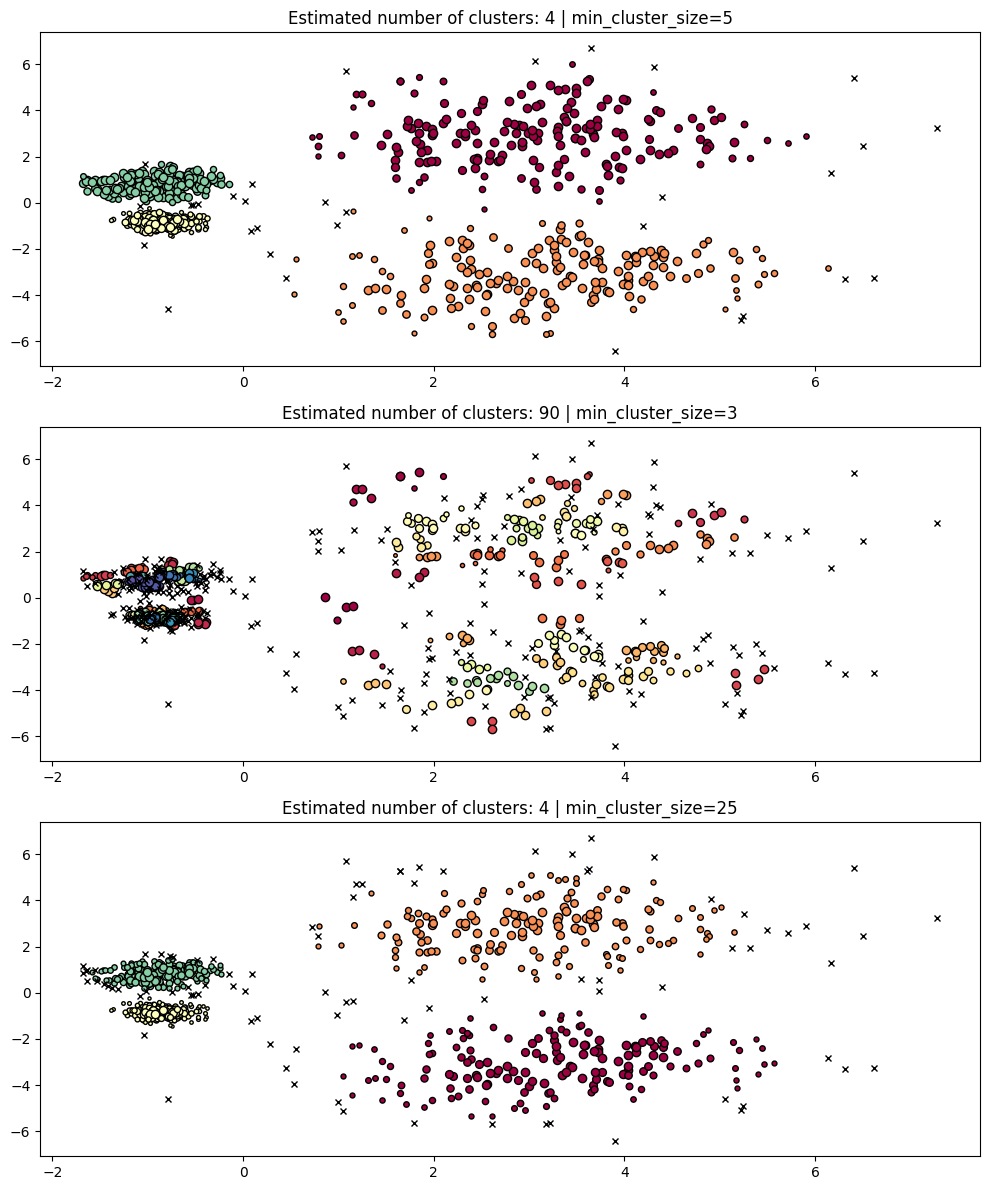

In [18]:
from sklearn.cluster import HDBSCAN as SkHDBSCAN

PARAM = ({"min_cluster_size": 5}, {"min_cluster_size": 3}, {"min_cluster_size": 25})
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb_sk = SkHDBSCAN(**param).fit(X)
    plot(X, hdb_sk.labels_, hdb_sk.probabilities_, param, ax=axes[i])

for param in PARAM:
    lbl = SkHDBSCAN(**param).fit(X).labels_
    n_cluster = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"min_cluster_size={param['min_cluster_size']}: {n_cluster} cluster, {(lbl == -1).sum()} noise")

**Penjelasan:**<br>
Hasil eksperimen `min_cluster_size` menggunakan `sklearn.cluster.HDBSCAN`:

| min_cluster_size | Jumlah cluster | Noise |
|---|---|---|
| 5 | 4 | 32 |
| 3 | 90 | 254 |
| 25 | 4 | 90 |

Nilai `min_cluster_size=3` terlalu kecil sehingga hasilnya terfragmentasi menjadi 90 cluster kecil dan noise sangat tinggi (254 titik). Nilai 5 memberi hasil terbaik, yaitu 4 cluster sesuai struktur data dengan noise paling sedikit (32 titik). Nilai 25 masih menghasilkan 4 cluster, tetapi noise meningkat menjadi 90 titik karena titik di tepi cluster renggang tidak memenuhi ambang ukuran cluster. Dengan demikian, `min_cluster_size` yang terlalu kecil menyebabkan fragmentasi, yang terlalu besar menambah noise, dan nilai menengah memberi keseimbangan terbaik pada data ini.

## **Langkah 8: Eksperimen Hyperparameter min_samples**

min_samples=5: 4 cluster, 32 noise
min_samples=3: 4 cluster, 19 noise
min_samples=25: 4 cluster, 90 noise


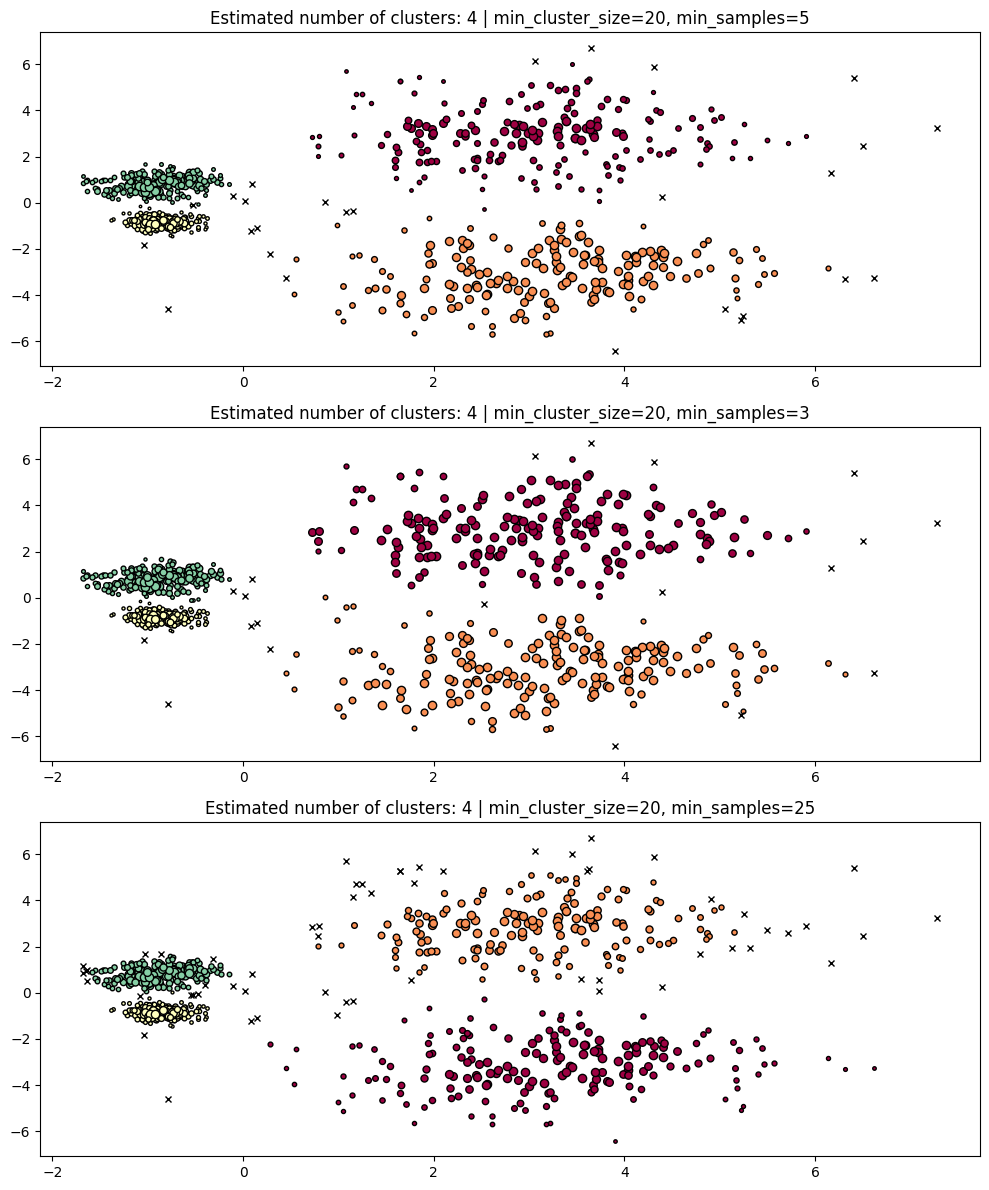

In [17]:
PARAM = (
    {"min_cluster_size": 20, "min_samples": 5},
    {"min_cluster_size": 20, "min_samples": 3},
    {"min_cluster_size": 20, "min_samples": 25},
)
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    hdb = hdbscan.HDBSCAN(**param).fit(X)
    plot(X, hdb.labels_, hdb.probabilities_, param, ax=axes[i])

for param in PARAM:
    lbl = SkHDBSCAN(**param).fit(X).labels_
    n_cluster = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"min_samples={param['min_samples']}: {n_cluster} cluster, {(lbl == -1).sum()} noise")

**Penjelasan:**<br>
Pada eksperimen ini `min_cluster_size` ditetapkan 20 dan hanya `min_samples` yang diubah (`sklearn.cluster.HDBSCAN`).

| min_samples | Jumlah cluster | Noise |
|---|---|---|
| 3 | 4 | 19 |
| 5 | 4 | 32 |
| 25 | 4 | 90 |

Jumlah cluster tetap 4 pada ketiga nilai `min_samples`, tetapi jumlah noise terus meningkat seiring naiknya `min_samples`: 19 titik pada nilai 3, 32 titik pada nilai 5, dan 90 titik pada nilai 25. `min_samples` menentukan seberapa konservatif HDBSCAN dalam menilai kepadatan suatu titik. Semakin besar nilainya, semakin banyak tetangga yang dibutuhkan agar suatu titik dianggap berada di area padat, sehingga titik di tepi cluster renggang lebih mudah dikategorikan sebagai noise. Struktur utama keempat cluster tetap bertahan, hanya batas cluster yang menyempit.

## **Langkah 9: DBSCAN Clustering dari Pohon HDBSCAN**

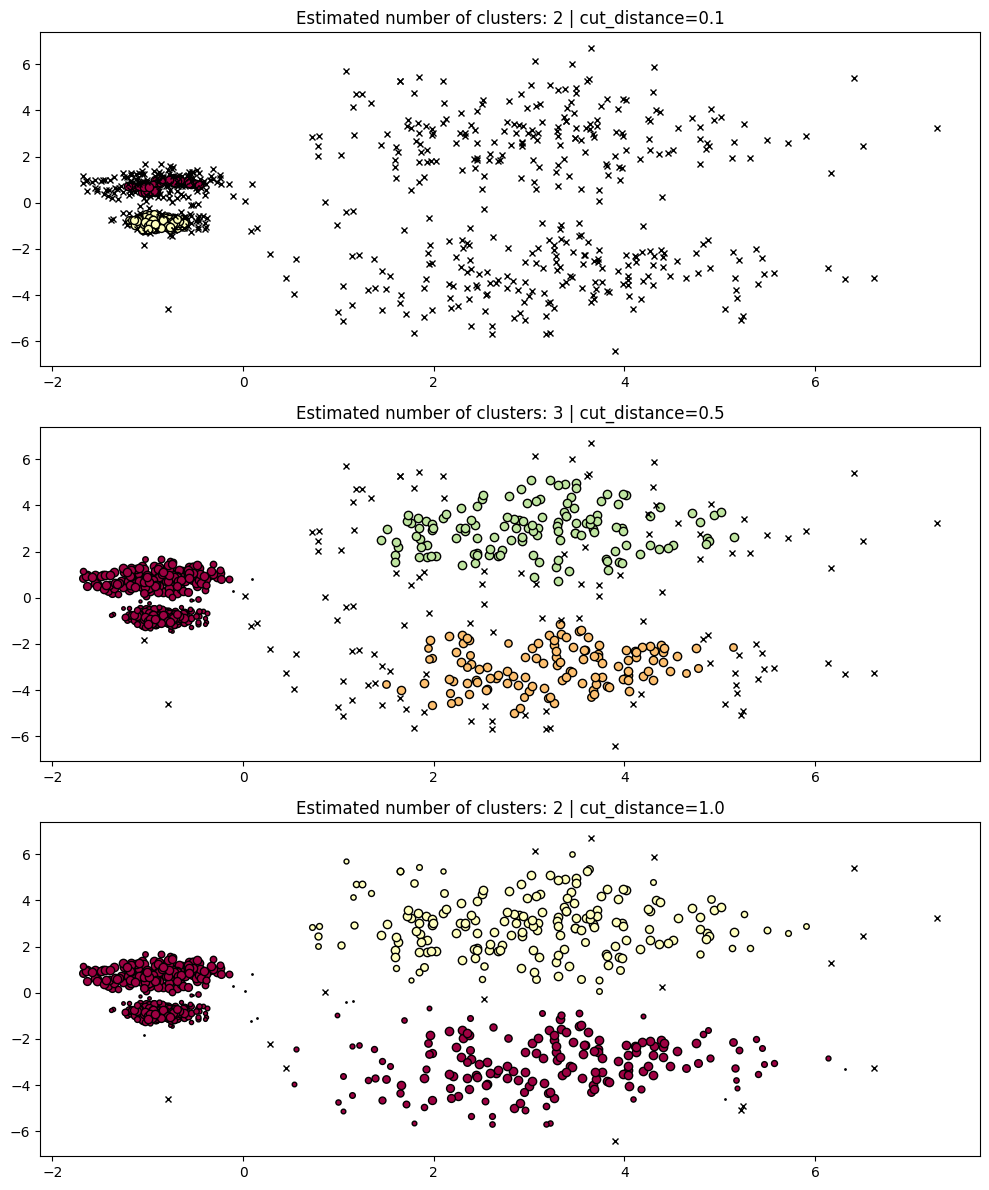

In [13]:
PARAM = (
    {"cut_distance": 0.1},
    {"cut_distance": 0.5},
    {"cut_distance": 1.0},
)
hdb = hdbscan.HDBSCAN().fit(X)
fig, axes = plt.subplots(len(PARAM), 1, figsize=(10, 12))
for i, param in enumerate(PARAM):
    labels = hdb.dbscan_clustering(**param)
    plot(X, labels, hdb.probabilities_, param, ax=axes[i])

**Penjelasan:**<br>
Pohon hierarki HDBSCAN dipotong pada tiga nilai `cut_distance`:
- `0.1`: 3 cluster, tetapi sebagian besar titik pada cluster renggang menjadi noise karena potongan terlalu rendah.
- `0.5`: 3 cluster, sebagian besar titik sudah terkelompok dengan noise yang lebih sedikit.
- `1.0`: hanya 1 cluster karena potongan terlalu tinggi sehingga semua kelompok menyatu.

Semakin besar `cut_distance`, semakin sedikit cluster yang terbentuk. Parameter ini mirip `eps` pada DBSCAN, tetapi diterapkan pada hierarki yang sudah dibangun sehingga berbagai tingkat detail dapat dicoba tanpa melakukan fit ulang.

## **Langkah 10: Evaluasi dengan Silhouette Score**

In [14]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk hasil clustering HDBSCAN
sil_score = silhouette_score(X, hdb.labels_)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.5743816709862986


**Penjelasan:**<br>
Silhouette Score yang diperoleh adalah **0.574**. Nilai ini berada di atas 0.5, yang menunjukkan bahwa sebagian besar titik cukup cocok dengan cluster-nya dan terpisah dari cluster lain, meskipun belum mendekati 1. Perlu dicatat bahwa titik noise (label -1) ikut dihitung sebagai satu kelompok sehingga dapat menurunkan skor.

## **Langkah 11: Evaluasi dengan Davies-Bouldin Index**

In [15]:
from sklearn.metrics import davies_bouldin_score

# Menghitung Davies-Bouldin Index untuk hasil clustering HDBSCAN
dbi_score = davies_bouldin_score(X, hdb.labels_)
print(f"Davies-Bouldin Index: {dbi_score}")

Davies-Bouldin Index: 1.6436030674842066


**Penjelasan:**<br>
Davies-Bouldin Index yang diperoleh adalah **1.644**. Semakin kecil nilainya semakin baik, dan nilai di atas 1 menunjukkan bahwa cluster belum terpisah sempurna dan masih ada tumpang tindih atau sebaran yang cukup besar di dalam cluster. Hasil ini sejalan dengan Silhouette Score yang menunjukkan kualitas clustering cukup baik namun belum ideal.

## **Langkah 12: Visualisasi Hasil Evaluasi**

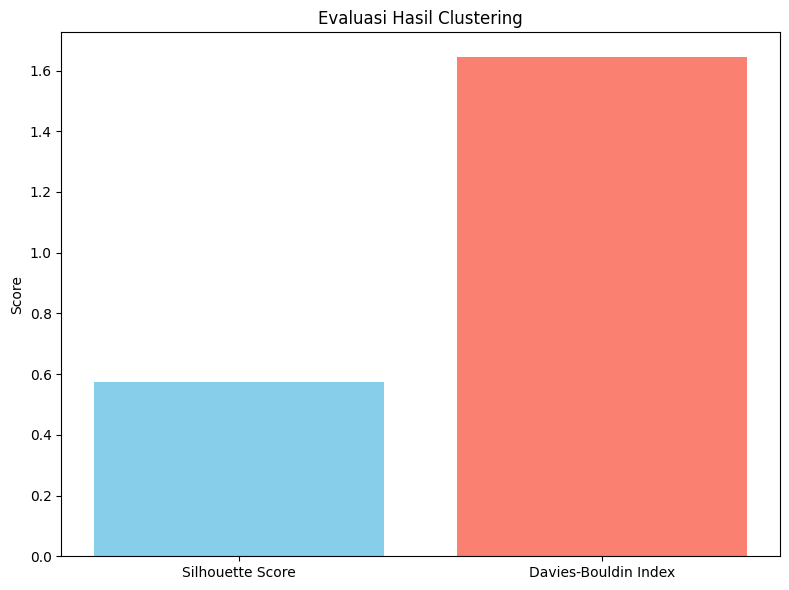

In [16]:
# Misalnya kita ingin membandingkan DBI dan Silhouette Score untuk beberapa eksperimen
scores = {
    "Silhouette Score": sil_score,
    "Davies-Bouldin Index": dbi_score
}

# Plot hasil evaluasi
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon'])
ax.set_title("Evaluasi Hasil Clustering")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

**Penjelasan:**<br>
Grafik batang membandingkan Silhouette Score (0.574) dan Davies-Bouldin Index (1.644). Kedua metrik memiliki arah interpretasi yang berbeda: Silhouette Score yang lebih tinggi lebih baik, sedangkan Davies-Bouldin Index yang lebih rendah lebih baik. Karena skalanya berbeda, grafik ini lebih berguna untuk membandingkan beberapa eksperimen dengan metrik yang sama daripada membandingkan kedua metrik satu sama lain.